# SignalShap — Full Study on Apple Silicon (M4, 48 GB)

Runs the complete study at a scale the CI sandbox could not reach. The sandbox was capped at
**3 GB RAM / 1,500 users**; here we auto-size each corpus to a memory budget you control.

**What this notebook produces**
1. Four real corpora (MovieLens-1M + the three LightGCN benchmark splits)
2. E0 preconditions → exact Shapley → LOO comparison
3. **E9 redundancy intervention** — the paper's central claim, with ground truth by construction
4. Full experiment suite on every corpus (robustness, segments, fusion, LightGCN/SASRec)
5. Regenerated `paper/` figures and tables

**Expect ~45–90 min** for the full run. Every step is checkpointed to `artefacts/`, so you
can interrupt and resume.

> **Why memory dominates.** The game holds five dense `n_users × n_items` float32 score
> matrices simultaneously. Amazon-Book at full size is **96 GB** — beyond 48 GB — so
> subsampling is unavoidable there and is disclosed in the paper rather than hidden.

## 1 · Environment

Apple Silicon note: install NumPy/SciPy via `pip` wheels, which link against **Accelerate** and are already well optimised for M-series. No CUDA anywhere — the entire pipeline is CPU-only by design.

In [2]:
import platform, os, sys, subprocess
print("python :", platform.python_version())
print("machine:", platform.machine(), "|", platform.platform())
if platform.machine() != "arm64":
    print("  note: not arm64 — you may be under Rosetta; a native arm64 Python is faster.")

# Physical RAM (macOS)
try:
    ram = int(subprocess.check_output(["sysctl","-n","hw.memsize"]).strip())/1e9
    print(f"RAM    : {ram:.0f} GB")
except Exception:
    ram = 48.0
    print("RAM    : assuming 48 GB")

python : 3.12.13
machine: arm64 | macOS-26.5.1-arm64-arm-64bit
RAM    : 52 GB


In [3]:
%pip install -q numpy pandas scipy scikit-learn matplotlib pyyaml pyarrow tabulate jinja2 nbformat
import numpy as np, pandas as pd
print("numpy", np.__version__, "| pandas", pd.__version__)
np.show_config()  # confirm Accelerate / OpenBLAS backing


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
numpy 2.5.1 | pandas 3.0.5
Build Dependencies:
  blas:
    detection method: system
    found: true
    include directory: unknown
    lib directory: unknown
    name: accelerate
    openblas configuration: unknown
    pc file directory: unknown
    version: unknown
  lapack:
    detection method: system
    found: true
    include directory: unknown
    lib directory: unknown
    name: accelerate
    openblas configuration: unknown
    pc file directory: unknown
    version: unknown
Compilers:
  c:
    commands: cc
    linker: ld64
    name: clang
    version: 15.0.0
  c++:
    commands: c++
    linker: ld64
    name: clang
    version: 15.0.0
  cython:
    commands: cython
    linker: cython
    name: cython
    version: 3.2.8
Machine Information:
  build:
    cpu: aarch64
    endian: little
    family: aarch6

### Repo and data

Clone the repo, then fetch corpora. MovieLens-1M is already committed; the three LightGCN
splits come from `scripts/fetch_benchmarks.sh` (~37 MB).

In [4]:
from pathlib import Path
import os, sys, subprocess

REPO = Path.home()/"signalshap-code"      # <-- edit if you cloned elsewhere
if not REPO.exists():
    subprocess.run(["git","clone",
        "https://github.com/mouadlouhichi/signalshap-code.git", str(REPO)], check=True)
os.chdir(REPO); sys.path.insert(0, str(REPO/"src"))
print("cwd:", Path.cwd())

# Benchmark corpora (idempotent)
if not (REPO/"data"/"raw"/"gowalla").exists():
    r = subprocess.run(["bash","scripts/fetch_benchmarks.sh"],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print("fetch script failed; falling back to an inline download")
        print(" ", (r.stderr or r.stdout).strip()[:200])
        import tarfile, io, urllib.request, shutil
        url = "https://codeload.github.com/kuandeng/LightGCN/tar.gz/refs/heads/master"
        buf = io.BytesIO(urllib.request.urlopen(url, timeout=300).read())
        with tarfile.open(fileobj=buf) as t:
            t.extractall("/tmp/_lg")
        for d in ("gowalla","yelp2018","amazon-book"):
            shutil.copytree(f"/tmp/_lg/LightGCN-master/Data/{d}",
                            REPO/"data"/"raw"/d, dirs_exist_ok=True)
        print("  corpora fetched inline")

# MovieLens-1M lives at data/ml-1m/ ; the loader searches data/raw/, data/, and root
for p in ["data/ml-1m","data/raw/gowalla","data/raw/yelp2018","data/raw/amazon-book"]:
    print(("  OK   " if Path(p).exists() else "  MISS "), p)

cwd: /Users/mlouhichi/signalshap-code
  MISS  data/ml-1m
  OK    data/raw/gowalla
  OK    data/raw/yelp2018
  OK    data/raw/amazon-book


## 2 · Memory budget and auto-sizing

Set `SCORE_BUDGET_GB` to how much RAM the five score matrices may occupy. Users per corpus
are then derived, not guessed:

$$\text{max\_users} = \frac{\text{budget}}{5 \times n_{items} \times 4\text{ bytes}}$$

On 48 GB, **16 GB is a safe default** — it leaves room for the coalition machinery, the ridge
fits, and the OS. Raise it if you have headroom; lower it if you hit swap.

In [5]:
SCORE_BUDGET_GB = 16.0        # <-- the one knob that matters
SEEDS           = (42, 43, 44)
CORPORA         = ["ml_1m", "yelp2018", "gowalla", "amazon_book_lgcn"]

ITEMS = {"ml_1m": 3533, "gowalla": 40981, "yelp2018": 38048, "amazon_book_lgcn": 91599}
FULL  = {"ml_1m": 6038, "gowalla": 29858, "yelp2018": 31668, "amazon_book_lgcn": 52643}

plan = {}
for k in CORPORA:
    cap = int(SCORE_BUDGET_GB*1e9 / (5*ITEMS[k]*4))
    plan[k] = min(cap, FULL[k])
    pct = 100*plan[k]/FULL[k]
    print(f"  {k:18s} items={ITEMS[k]:6d}  users={plan[k]:6d}/{FULL[k]:6d} "
          f"({pct:5.1f}%)  {'FULL' if plan[k]>=FULL[k] else 'subsampled'}")
print(f"\nSandbox ran 1,500 users/corpus at 3 GB — this is a large scale-up.")

  ml_1m              items=  3533  users=  6038/  6038 (100.0%)  FULL
  yelp2018           items= 38048  users= 21026/ 31668 ( 66.4%)  subsampled
  gowalla            items= 40981  users= 19521/ 29858 ( 65.4%)  subsampled
  amazon_book_lgcn   items= 91599  users=  8733/ 52643 ( 16.6%)  subsampled

Sandbox ran 1,500 users/corpus at 3 GB — this is a large scale-up.


## 3 · Pre-registered configuration

`configs/frozen.yaml` holds values fixed **before** results were seen: per-corpus `N_max`,
the frozen ridge `λ`, and the `v₀` permutation seed. `λ` is *never* tuned per coalition —
doing so is optimistic bias that grows with `|S|`.

In [6]:
from signalshap.config import FrozenConfig, SOURCES, write_artefact, read_artefact

cfg = FrozenConfig.load()
print("sources:", SOURCES)
print("N_max  :", cfg.n_max)
print("lambda :", cfg.ridge_lambda, "(frozen)")
print("gate   : candidate recall >=", cfg.recall_gate)

sources: ('cf', 'ct', 'pop', 'rec', 'seq')
N_max  : {'ml_1m': 600, 'lastfm_2k': 500, 'amazon_book': 1000, 'gowalla': 2500, 'yelp2018': 5000, 'amazon_book_lgcn': 5000}
lambda : 1.0 (frozen)
gate   : candidate recall >= 0.6


## 4 · Load corpora and check the density ordering

Density is **computed as-used**, never quoted from a source paper — the subsample alone
moves it. The four corpora should span roughly 25×.

⚠️ The LightGCN splits carry **no timestamps**, so leave-last-out *temporal* splitting applies
to MovieLens only. On the others, interaction order is arbitrary, which structurally
handicaps the `rec` and `seq` players — their attributions there are **lower bounds**.

In [7]:
import warnings, gc
from signalshap.data.loaders import load_dataset, build_dataset_stats

datasets, rows = {}, []
for k in CORPORA:
    os.environ["SIGNALSHAP_MAX_USERS"] = str(plan[k])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ds = load_dataset(k)
    datasets[k] = ds
    s = ds.stats()
    rows.append({"corpus": k, "users": s["users"], "items": s["items"],
                 "interactions": s["interactions"],
                 "density %": round(s["density"]*100, 4),
                 "temporal split": not s.get("no_timestamps", False),
                 "real": not s["synthetic"]})
display(pd.DataFrame(rows).sort_values("density %", ascending=False))

stats = build_dataset_stats(datasets)
write_artefact("dataset_stats.json", stats)
d = {k: stats[k]["density"] for k in CORPORA}
print(f"density range: {max(d.values())/min(d.values()):.0f}x "
      f"({min(d.values())*100:.4f}% .. {max(d.values())*100:.4f}%)")

[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
[signalshap] yelp2018: loaded REAL data (21,026 users x 38,048 items, 839,455 interactions)
[signalshap] gowalla: loaded REAL data (19,521 users x 40,981 items, 549,280 interactions)
[signalshap] amazon_book_lgcn: loaded REAL data (8,733 users x 86,537 items, 398,784 interactions)


,corpus,users,items,interactions,density %,temporal split,real
0,ml_1m,6038,3533,575276,2.6967,True,True
1,yelp2018,21026,38048,839455,0.1049,False,True
2,gowalla,19521,40981,549280,0.0687,False,True
3,amazon_book_lgcn,8733,86537,398784,0.0528,False,True


density range: 51x (0.0528% .. 2.6967%)


## 5 · E9 — the redundancy intervention (run this first)

**This is the paper's central claim, so it runs before anything else.**

Observational comparison can only show LOO and Shapley *differ*; it cannot say which is
right. Here we inject a known duplicate of a real source, holding candidates fixed, which
fixes the correct answer by construction:

- **Symmetry** → the duplicated pair must receive *equal* credit
- **Property 2** → LOO must *collapse to zero* for both

If exact Shapley fails this, the method is wrong and the experiment says so.

In [8]:
import time
from signalshap.pipeline import Experiment
from signalshap.experiments.recovery import recovery_experiment, summarise

recovery = {}   # reloaded from disk below if the kernel restarted
for k in CORPORA:
    os.environ["SIGNALSHAP_MAX_USERS"] = str(plan[k])
    t0 = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        exp = Experiment(k, cfg, seed=42, synthetic=False)
        rec = recovery_experiment(exp, "cf", etas=(0.0, 0.01, 0.1, 0.5), seed=42)
    recovery[k] = rec
    write_artefact(f"e9_recovery_{k}.json", rec)
    c = rec["conditions"]["eta=0.0"]
    print(f"{k:18s} {time.time()-t0:5.0f}s  symmetry_err={c['symmetry_abs_error']:.2e}  "
          f"LOO={c['loo_original']:.5f}/{c['loo_duplicate']:.5f}", flush=True)
    del exp; gc.collect()

# Survive a kernel restart: rehydrate from artefacts rather than recomputing.
for k in CORPORA:
    if k not in recovery and Path(f"artefacts/e9_recovery_{k}.json").exists():
        recovery[k] = read_artefact(f"e9_recovery_{k}.json")
        print(f"{k:18s} loaded from artefacts")

[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
    [E9 ml_1m] eta=0.0 (1/4) -- 2^6=64 coalitions...
    [E9 ml_1m] eta=0.0 done in 24.6s  symmetry_err=0.00e+00
    [E9 ml_1m] eta=0.01 (2/4) -- 2^6=64 coalitions...
    [E9 ml_1m] eta=0.01 done in 24.6s  symmetry_err=3.03e-05
    [E9 ml_1m] eta=0.1 (3/4) -- 2^6=64 coalitions...
    [E9 ml_1m] eta=0.1 done in 24.4s  symmetry_err=4.12e-05
    [E9 ml_1m] eta=0.5 (4/4) -- 2^6=64 coalitions...
    [E9 ml_1m] eta=0.5 done in 24.6s  symmetry_err=4.45e-05
ml_1m                130s  symmetry_err=0.00e+00  LOO=0.00000/0.00000
[signalshap] yelp2018: loaded REAL data (21,026 users x 38,048 items, 839,455 interactions)
    [E9 yelp2018] eta=0.0 (1/4) -- 2^6=64 coalitions...
    [E9 yelp2018] eta=0.0 done in 886.0s  symmetry_err=0.00e+00
    [E9 yelp2018] eta=0.01 (2/4) -- 2^6=64 coalitions...
    [E9 yelp2018] eta=0.01 done in 1008.4s  symmetry_err=7.23e-06
    [E9 yelp2018] eta=0.1 (3/4) -- 2^6=64 coalitions..

In [9]:
summary = pd.DataFrame([{
    "corpus": k,
    "density %": round(stats[k]["density"]*100, 4),
    "phi_cf": round(r["conditions"]["eta=0.0"]["phi_original"], 5),
    "phi_cf_dup": round(r["conditions"]["eta=0.0"]["phi_duplicate"], 5),
    "symmetry err": f"{r['conditions']['eta=0.0']['symmetry_abs_error']:.1e}",
    "LOO(cf)": round(r["conditions"]["eta=0.0"]["loo_original"], 5),
    "LOO(dup)": round(r["conditions"]["eta=0.0"]["loo_duplicate"], 5),
} for k, r in recovery.items()])
display(summary)

ok = all(r["conditions"]["eta=0.0"]["symmetry_abs_error"] < 1e-6 for r in recovery.values())
print("Shapley recovers symmetry on every corpus:", ok)
print("LOO collapses to ~0 on every corpus     :",
      all(abs(r["conditions"]["eta=0.0"]["loo_original"]) < 1e-6 for r in recovery.values()))
print("\n-> An engineer running standard ablation on a system with two redundant")
print("   components is told NEITHER contributes, and would retire both.")

,corpus,density %,phi_cf,phi_cf_dup,symmetry err,LOO(cf),LOO(dup)
0,ml_1m,2.6967,0.01078,0.01078,0.0e+00,0.0,0.0
1,yelp2018,0.1049,0.00618,0.00618,0.0e+00,0.0,0.0
2,gowalla,0.0687,0.01429,0.01429,0.0e+00,0.0,0.0
3,amazon_book_lgcn,0.0528,0.00251,0.00251,0.0e+00,0.0,0.0


Shapley recovers symmetry on every corpus: True
LOO collapses to ~0 on every corpus     : True

-> An engineer running standard ablation on a system with two redundant
   components is told NEITHER contributes, and would retire both.


### Graceful degradation

As η grows the duplicate becomes a noisier copy, exact redundancy weakens, and LOO becomes non-zero but erratic in sign — the behaviour Lemma 1(i) describes for ε-redundancy.

In [10]:
recovery = recovery if "recovery" in dir() else {
    k: read_artefact(f"e9_recovery_{k}.json") for k in CORPORA
    if Path(f"artefacts/e9_recovery_{k}.json").exists()}

for k, r in recovery.items():
    print(f"\n{k}"); print(summarise(r).split("\n", 2)[2])


ml_1m
   eta   phi_orig    phi_dup   sym.err   pair_sum  conserv   LOO_orig    LOO_dup
  0.00    0.01078    0.01078   0.00000    0.02156    1.419    0.00000    0.00000
  0.01    0.01092    0.01089   0.00003    0.02180    1.435    0.00062    0.00043
  0.10    0.01093    0.01089   0.00004    0.02181    1.435    0.00074    0.00060
  0.50    0.01050    0.01046   0.00004    0.02096    1.379   -0.00178    0.00034

pre-injection phi_cf = 0.01520; pre-injection LOO = -0.00478

yelp2018
   eta   phi_orig    phi_dup   sym.err   pair_sum  conserv   LOO_orig    LOO_dup
  0.00    0.00618    0.00618   0.00000    0.01235    1.282    0.00000    0.00000
  0.01    0.00618    0.00617   0.00001    0.01235    1.283    0.00003   -0.00003
  0.10    0.00611    0.00624   0.00013    0.01234    1.282   -0.00016   -0.00005
  0.50    0.00608    0.00627   0.00019    0.01236    1.283   -0.00028   -0.00005

pre-injection phi_cf = 0.00963; pre-injection LOO = 0.00052

gowalla
   eta   phi_orig    phi_dup   sym.err   

## 6 · Full experiment suite

E0 preconditions, exact Shapley, LOO, segments, fusion, robustness, and the LightGCN /
SASRec baselines. Checkpointed per corpus.

Memory note: `run_all()` holds the score matrices *and* the robustness sweeps. If a corpus
OOMs, lower `SCORE_BUDGET_GB` and re-run — only the failed corpus repeats.

In [11]:
from signalshap.pipeline import run_multi_seed

def _free_gb():
    """Available RAM in GB (macOS: free + inactive pages)."""
    try:
        vm = subprocess.check_output(["vm_stat"]).decode()
        pg = int(vm.split("page size of")[1].split("bytes")[0])
        d = {l.split(":")[0].strip(): int(l.split(":")[1].strip().rstrip("."))
             for l in vm.splitlines() if ":" in l and l.split(":")[1].strip().rstrip(".").isdigit()}
        return (d.get("Pages free",0)+d.get("Pages inactive",0))*pg/1e9
    except Exception:
        return 999.0

# run_all() holds the score matrices AND, at peak, a second game plus the two
# neural baselines -- roughly 2.4x the score-matrix footprint. On a 48 GB
# machine yelp2018/gowalla peak near 38 GB, which leaves nothing for macOS and
# Jupyter. We therefore size each corpus against ACTUALLY FREE memory and skip
# rather than die, so one large corpus cannot lose the whole run.
# Peak is now ~1.6x the score-matrix footprint, down from ~2.4x: the neural
# baselines release their matrix immediately after scoring, and the per-user
# feature blocks are float32. If a corpus still skips, lower SCORE_BUDGET_GB
# in cell 2 -- the AUTO_DOWNSIZE block below does that for you.
PEAK_MULTIPLIER = 1.6

results = {}
for k in CORPORA:
    out = Path(f"artefacts/results_{k}.json")
    if out.exists() and os.environ.get("FORCE_RERUN") != "1":
        r = read_artefact(out.name)
        if r.get("dataset_stats", {}).get("users") == plan[k]:
            results[k] = r; print(f"{k:18s} cached (matches current plan)"); continue
        print(f"{k:18s} cached at {r.get('dataset_stats',{}).get('users')} users "
              f"!= plan {plan[k]} -- STALE, re-running")

    # AUTO_DOWNSIZE: rather than skipping, shrink this corpus to whatever
    # actually fits. A smaller real run beats no run -- and beats silently
    # leaving a stale file behind that later contaminates the tables.
    free = _free_gb()
    need = PEAK_MULTIPLIER * 5 * plan[k] * ITEMS[k] * 4 / 1e9
    n_users = plan[k]
    if need > free * 0.80:
        n_users = int(free * 0.80 / (PEAK_MULTIPLIER * 5 * ITEMS[k] * 4) * 1e9)
        if n_users < 1000:
            print(f"{k:18s} SKIP: even 1,000 users needs more than {free:.0f} GB free.")
            continue
        print(f"{k:18s} downsizing {plan[k]:,} -> {n_users:,} users "
              f"(needs ~{need:.0f} GB, {free:.0f} GB free)")
        plan[k] = n_users

    os.environ["SIGNALSHAP_MAX_USERS"] = str(n_users)
    t0 = time.time()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            exp = Experiment(k, cfg, seed=42, synthetic=False)
            r = exp.run_all()
            r["multi_seed"] = run_multi_seed(k, cfg, SEEDS, False)
            if k in recovery: r["e9_recovery"] = recovery[k]
        write_artefact(f"results_{k}.json", r); results[k] = r
        a, b = r["e0a_candidates"], r["e0b_monotonicity"]
        print(f"{k:18s} {time.time()-t0:5.0f}s  recall={a['candidate_recall']:.3f} "
              f"({'PASS' if a['gate_passes'] else 'FAIL'})  monot={b['violations']}/80", flush=True)
        del exp, r
    except (MemoryError, np.core._exceptions._ArrayMemoryError) as e:
        print(f"{k:18s} OOM after {time.time()-t0:.0f}s -- lower SCORE_BUDGET_GB")
    gc.collect()

print(f"\nfull suite completed for: {sorted(results)}")

[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
ml_1m                310s  recall=0.748 (PASS)  monot=26/80
yelp2018           downsizing 21,026 -> 19,018 users (needs ~26 GB, 29 GB free)
[signalshap] yelp2018: loaded REAL data (19,018 users x 38,048 items, 756,903 interactions)
[signalshap] yelp2018: loaded REAL data (19,018 users x 38,048 items, 756,903 interactions)
[signalshap] yelp2018: loaded REAL data (19,018 users x 38,048 items, 756,903 interactions)
[signalshap] yelp2018: loaded REAL data (19,018 users x 38,048 items, 756,903 interactions)
yelp2018            7867s  recall=0.818 (PASS)  monot=0/80
gowalla            downsizing 19,521 -> 5,797 users (needs ~26 GB, 10 GB free)
[signa

### Preconditions come first

Candidate recall is the **ceiling** on every ranking metric — a test item outside $C_u$ scores
zero by construction. The monotonicity column decides whether Property 2 applies at all;
where it fails, negative $\varphi_g$ are substantive findings, not numerical error.

In [12]:
pre = pd.DataFrame([{
    "corpus": k,
    "density %": round(r["dataset_stats"]["density"]*100, 4),
    "N_max": r["e0a_candidates"]["n_max"],
    "recall": round(r["e0a_candidates"]["candidate_recall"], 3),
    "gate": "PASS" if r["e0a_candidates"]["gate_passes"] else "FAIL",
    "monot. viol": f"{r['e0b_monotonicity']['violations']}/80",
    "Prop2 applies": r["e0b_monotonicity"]["property2_applicable"],
    "efficiency err": f"{r['e1_source_share']['efficiency']['abs_error']:.1e}",
} for k, r in results.items()])
display(pre)
print("Any corpus below 0.60 -> spec §2.2 ladder: raise N_max first (rung 1).")

,corpus,density %,N_max,recall,gate,monot. viol,Prop2 applies,efficiency err
0,ml_1m,2.6967,600,0.748,PASS,26/80,False,6.9e-18
1,yelp2018,0.1046,5000,0.818,PASS,0/80,True,0.0e+00
2,gowalla,0.0719,2500,0.678,PASS,10/80,False,6.9e-18
3,amazon_book_lgcn,0.0547,5000,0.529,FAIL,10/80,False,1.7e-18


Any corpus below 0.60 -> spec §2.2 ladder: raise N_max first (rung 1).


### LOO vs Shapley — where they disagree in **sign**

In [13]:
rows = []
for k, r in results.items():
    e2 = r["e2_loo_vs_shapley"]
    for g in SOURCES:
        l, s_ = e2["loo"][g], e2["shapley"][g]
        rows.append({"corpus": k, "source": g, "LOO": round(l,5), "Shapley": round(s_,5),
                     "gap": round(s_-l,5), "SIGN FLIP": "yes" if l*s_ < 0 else ""})
df = pd.DataFrame(rows); display(df)
print("sign flips per corpus:")
print(df[df["SIGN FLIP"]=="yes"].groupby("corpus").size().to_string() or "  none")

,corpus,source,LOO,Shapley,gap,SIGN FLIP
0,ml_1m,cf,-0.00478,0.01520,0.01998,yes
1,ml_1m,ct,0.00109,-0.00017,-0.00126,yes
2,ml_1m,pop,0.00118,0.00629,0.00511,
3,ml_1m,rec,0.00033,0.00033,-0.00000,
4,ml_1m,seq,0.01672,0.02910,0.01238,
5,yelp2018,cf,0.00046,0.00984,0.00938,
6,yelp2018,ct,0.00000,0.00003,0.00003,
7,yelp2018,pop,0.00005,0.00242,0.00237,
8,yelp2018,rec,0.00000,0.00003,0.00003,
9,yelp2018,seq,0.00018,0.00499,0.00481,


sign flips per corpus:
corpus
amazon_book_lgcn    1
gowalla             1
ml_1m               2


### Fusion vs neural baselines

All methods evaluated **full-catalog**; SignalShap-Fuse scores items outside $C_u$ as $-\infty$ so its recall ceiling is a visible cost, not a hidden denominator advantage.

In [14]:
for k, r in results.items():
    e4 = r.get("e4_signalshap_fuse")
    if not e4: print(f"{k}: fusion not run"); continue
    print(f"\n=== {k} ===")
    display(pd.DataFrame([{"method": m, "NDCG@10": round(v["ndcg_at_10"],5),
                           "Recall@20": round(v["recall_at_20"],5)}
        for m, v in sorted(e4["full_catalog"].items(), key=lambda x:-x[1]["ndcg_at_10"])]))
    h = e4["holm_bonferroni"]
    for b, t in e4["wilcoxon"].items():
        print(f"   vs {b:22s} d={t['mean_diff']:+.5f}  Holm p={h['corrected'][b]:.4f}  "
              f"d_z={t['d_z']:+.3f}")


=== ml_1m ===


,method,NDCG@10,Recall@20
0,signalshap_fuse,0.06344,0.21094
1,global,0.06331,0.21044
2,uniform,0.05165,0.17680
3,lightgcn,0.03396,0.13074
4,popularity_reference,0.01829,0.07291
5,sasrec,0.00645,0.02336


   vs uniform                d=+0.01178  Holm p=0.0000  d_z=+0.097
   vs global                 d=+0.00013  Holm p=0.5917  d_z=+0.006
   vs popularity_reference   d=+0.04515  Holm p=0.0000  d_z=+0.232
   vs lightgcn               d=+0.02948  Holm p=0.0000  d_z=+0.157
   vs sasrec                 d=+0.05699  Holm p=0.0000  d_z=+0.300

=== yelp2018 ===


,method,NDCG@10,Recall@20
0,global,0.01951,0.06562
1,signalshap_fuse,0.01949,0.06583
2,uniform,0.01835,0.06199
3,lightgcn,0.01526,0.05495
4,popularity_reference,0.00349,0.01325
5,sasrec,0.00000,0.00011


   vs uniform                d=+0.00114  Holm p=0.0000  d_z=+0.038
   vs global                 d=-0.00001  Holm p=0.7565  d_z=-0.001
   vs popularity_reference   d=+0.01601  Holm p=0.0000  d_z=+0.146
   vs lightgcn               d=+0.00423  Holm p=0.0000  d_z=+0.041
   vs sasrec                 d=+0.01949  Holm p=0.0000  d_z=+0.182

=== gowalla ===


,method,NDCG@10,Recall@20
0,lightgcn,0.05103,0.12765
1,signalshap_fuse,0.05036,0.13403
2,global,0.05017,0.13369
3,uniform,0.04437,0.11730
4,popularity_reference,0.01282,0.03657
5,sasrec,0.00842,0.02053


   vs uniform                d=+0.00598  Holm p=0.0000  d_z=+0.087
   vs global                 d=+0.00018  Holm p=1.0000  d_z=+0.019
   vs popularity_reference   d=+0.03754  Holm p=0.0000  d_z=+0.220
   vs lightgcn               d=-0.00067  Holm p=1.0000  d_z=-0.005
   vs sasrec                 d=+0.04194  Holm p=0.0000  d_z=+0.234

=== amazon_book_lgcn ===


,method,NDCG@10,Recall@20
0,signalshap_fuse,0.01382,0.04325
1,global,0.01376,0.04338
2,uniform,0.01107,0.03409
3,lightgcn,0.00855,0.02951
4,popularity_reference,0.00205,0.00620
5,sasrec,0.00077,0.00283


   vs uniform                d=+0.00275  Holm p=0.0000  d_z=+0.062
   vs global                 d=+0.00006  Holm p=0.7123  d_z=+0.008
   vs popularity_reference   d=+0.01178  Holm p=0.0000  d_z=+0.124
   vs lightgcn               d=+0.00527  Holm p=0.0000  d_z=+0.062
   vs sasrec                 d=+0.01306  Holm p=0.0000  d_z=+0.140


## 7 · Paper assets

Regenerates F1–F7 and T1–T8 into `artefacts/`, which `paper/paper.tex` reads directly. No number is ever typed into the manuscript by hand.

In [15]:
from signalshap.plots.assets import generate_all_assets, FIG, TAB

# Only build paper assets from corpora whose results match the CURRENT plan.
# Mixing a 21k-user run with a stale 1.5k-user file would put two different
# scales in the same table with nothing to distinguish them.
consistent = {k: r for k, r in results.items()
              if r.get("dataset_stats", {}).get("users") == plan[k]}
dropped = sorted(set(results) - set(consistent))
if dropped:
    print("EXCLUDED from paper assets (scale mismatch):", dropped)
print("included:", sorted(consistent))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    assets = generate_all_assets(consistent, stats)
for kk, v in assets["figures"].items(): print(f"  {kk}: {v}")
print("  tables:", sorted(p.stem for p in TAB.glob("T*.md")))

included: ['amazon_book_lgcn', 'gowalla', 'ml_1m', 'yelp2018']
  F1: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F1_workflow.png
  F2: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F2_shapley_shares.png
  F3: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F3_loo_vs_shapley.png
  F4: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F4_redundancy_heatmap.png
  F5: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F5_segment_radar.png
  F6: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F6_fuse_gain.png
  F7: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F7_robustness.png
  tables: ['T1_positioning', 'T2_datasets', 'T3_notation', 'T4_cost', 'T5_main_results', 'T6_loo_vs_shapley', 'T7_fuse_significance', 'T8_robustness']


F2_shapley_shares


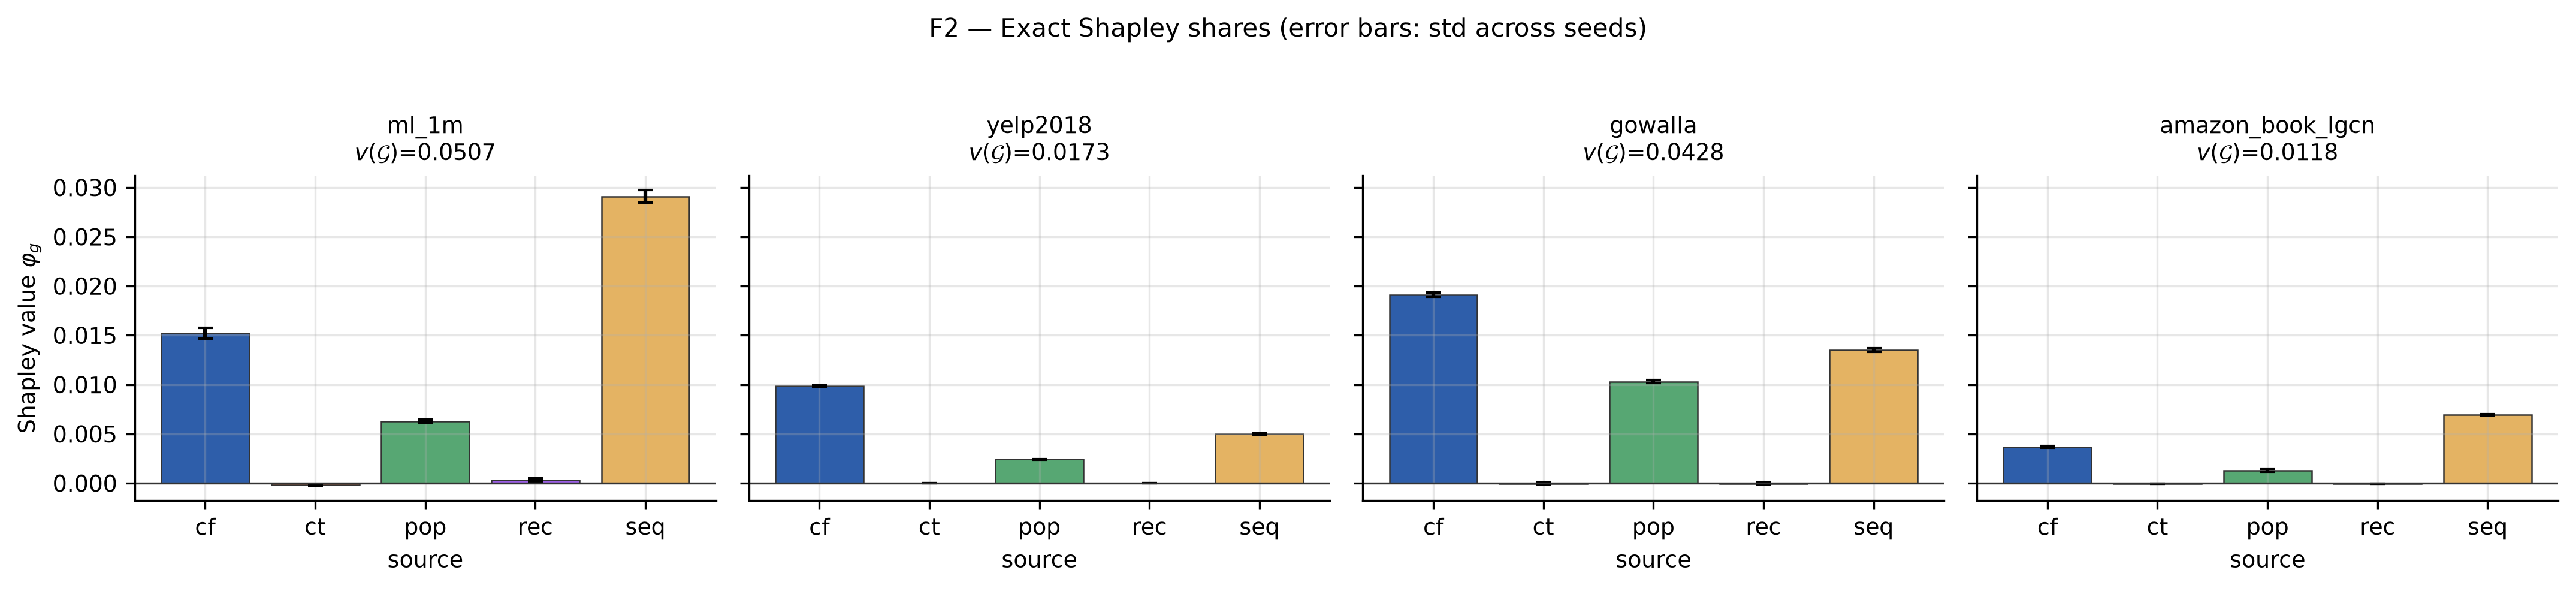

F3_loo_vs_shapley


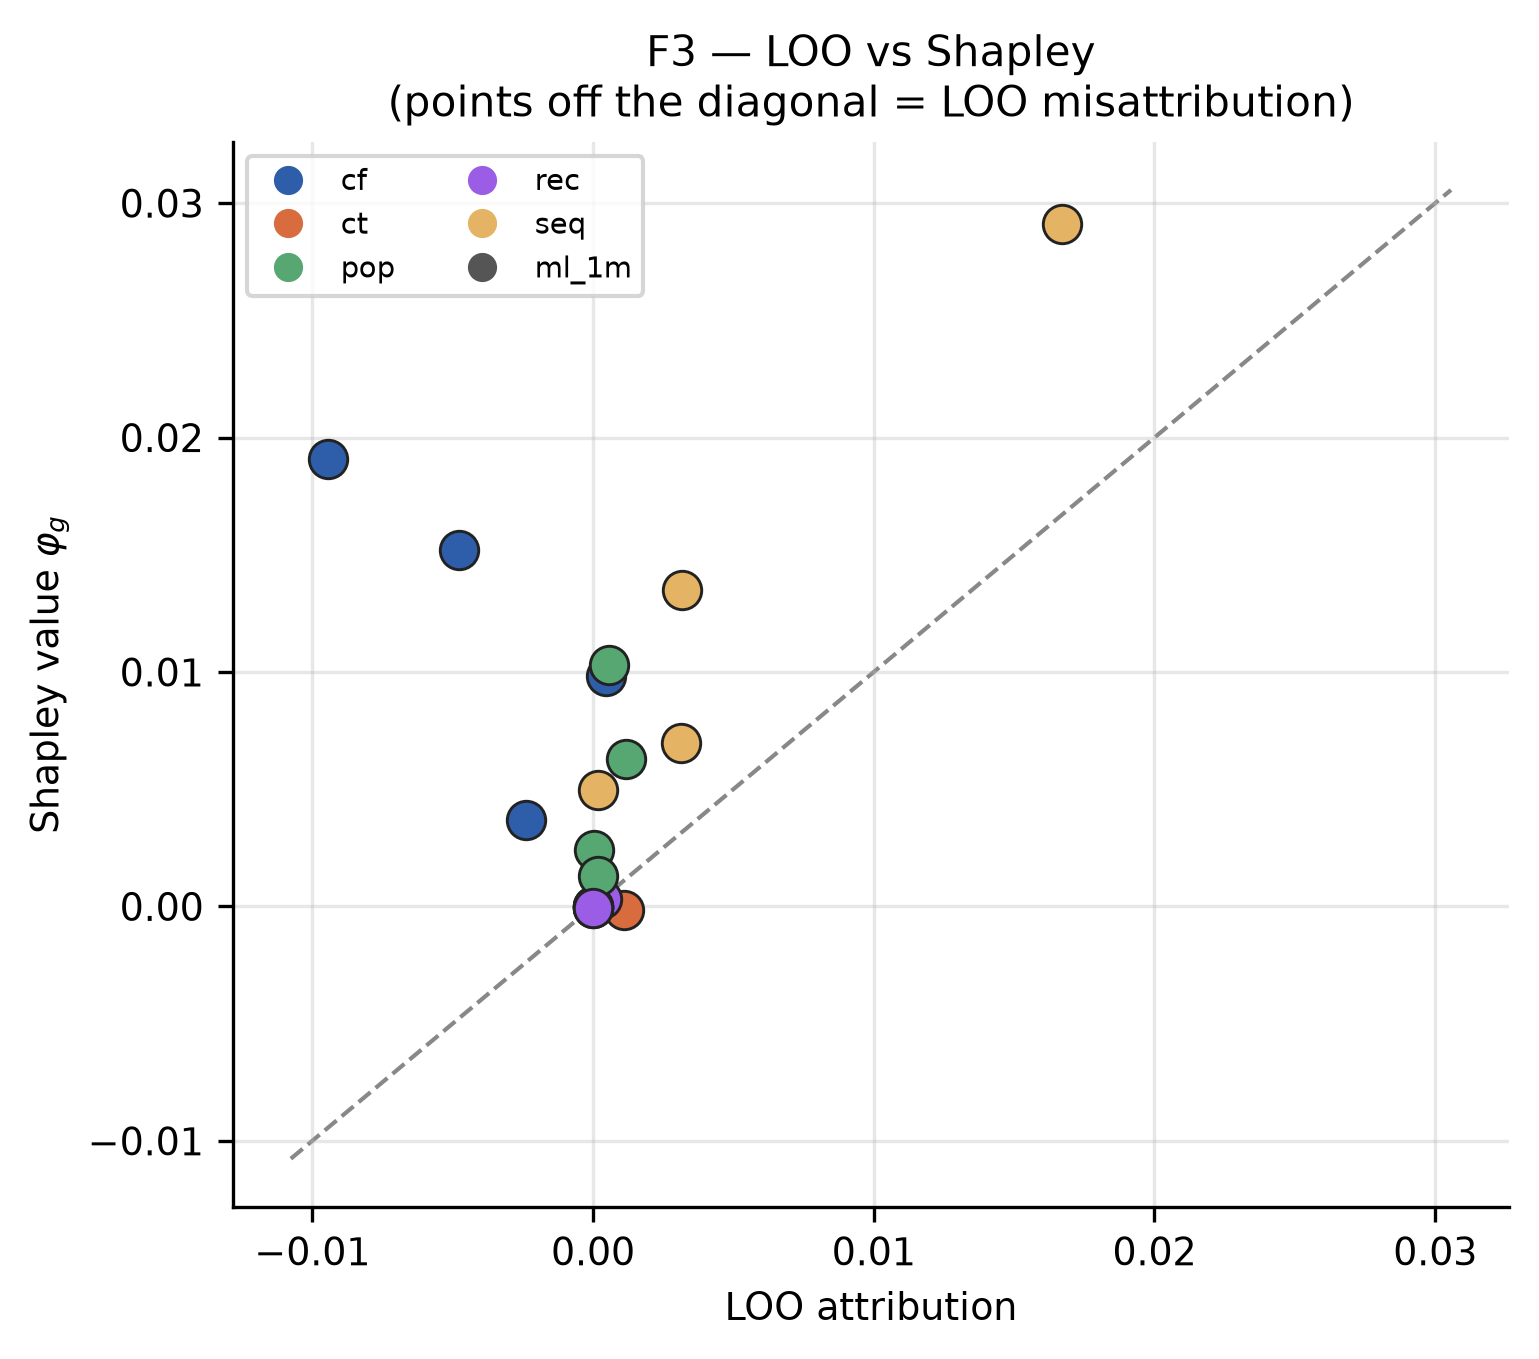

F4_redundancy_heatmap


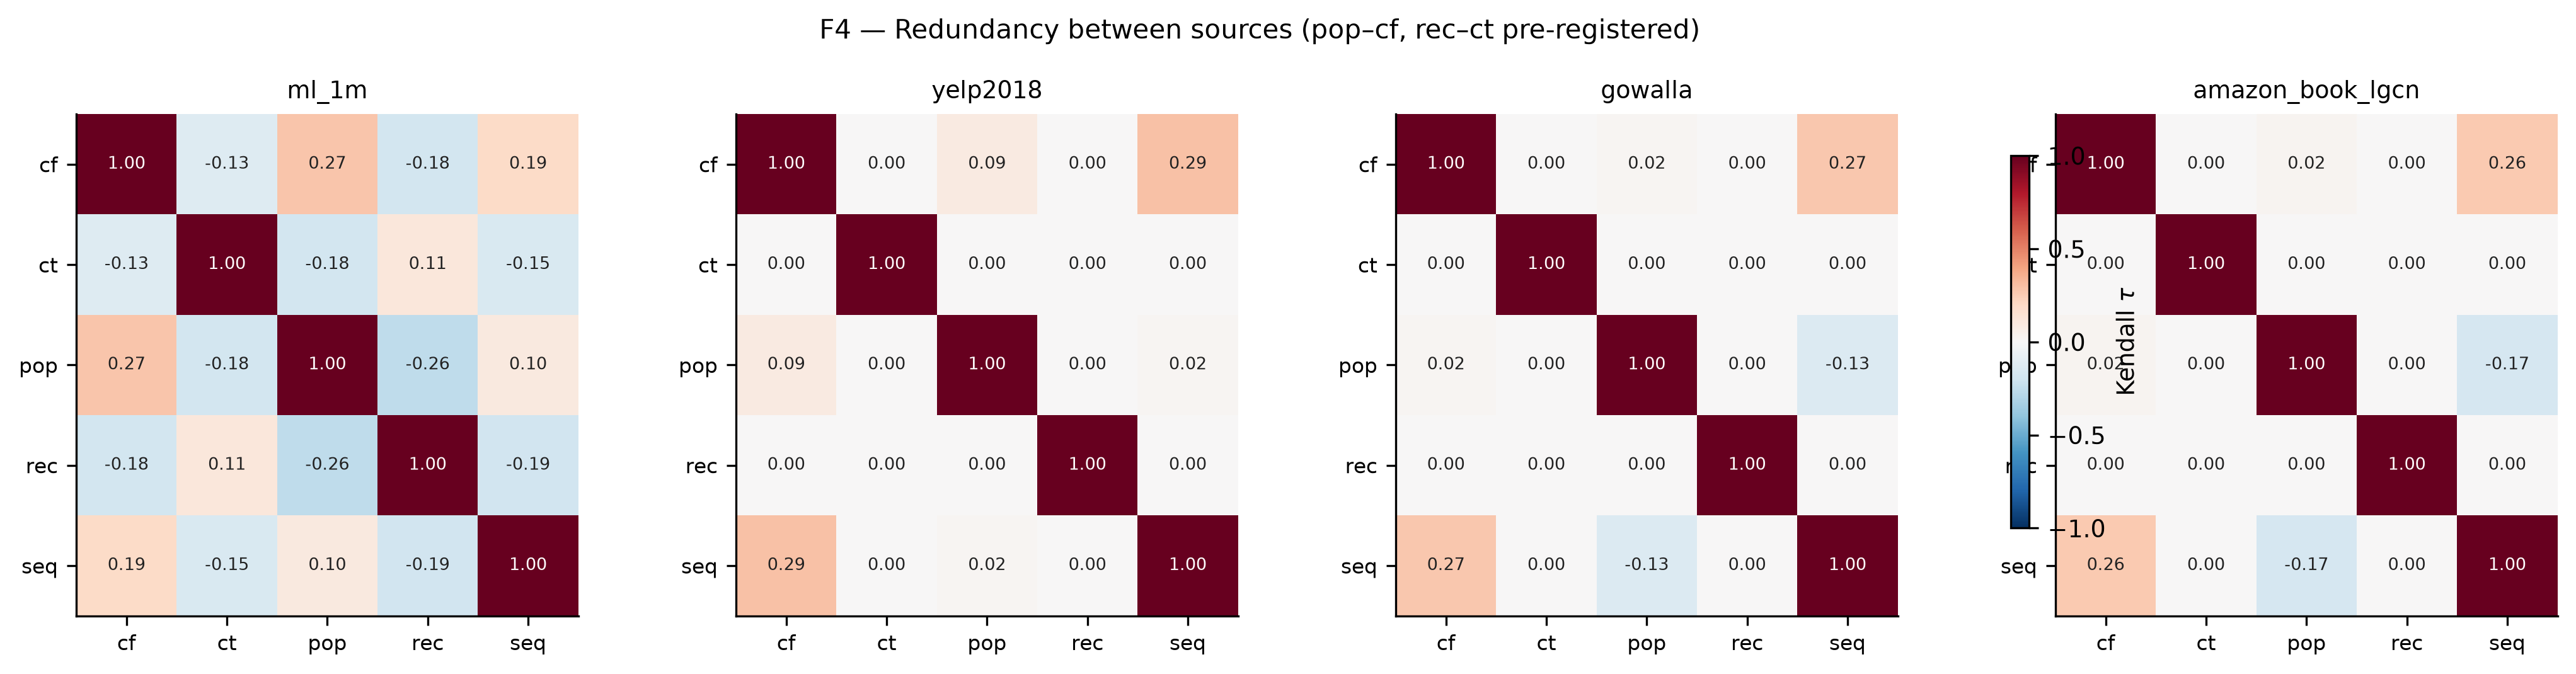

F6_fuse_gain


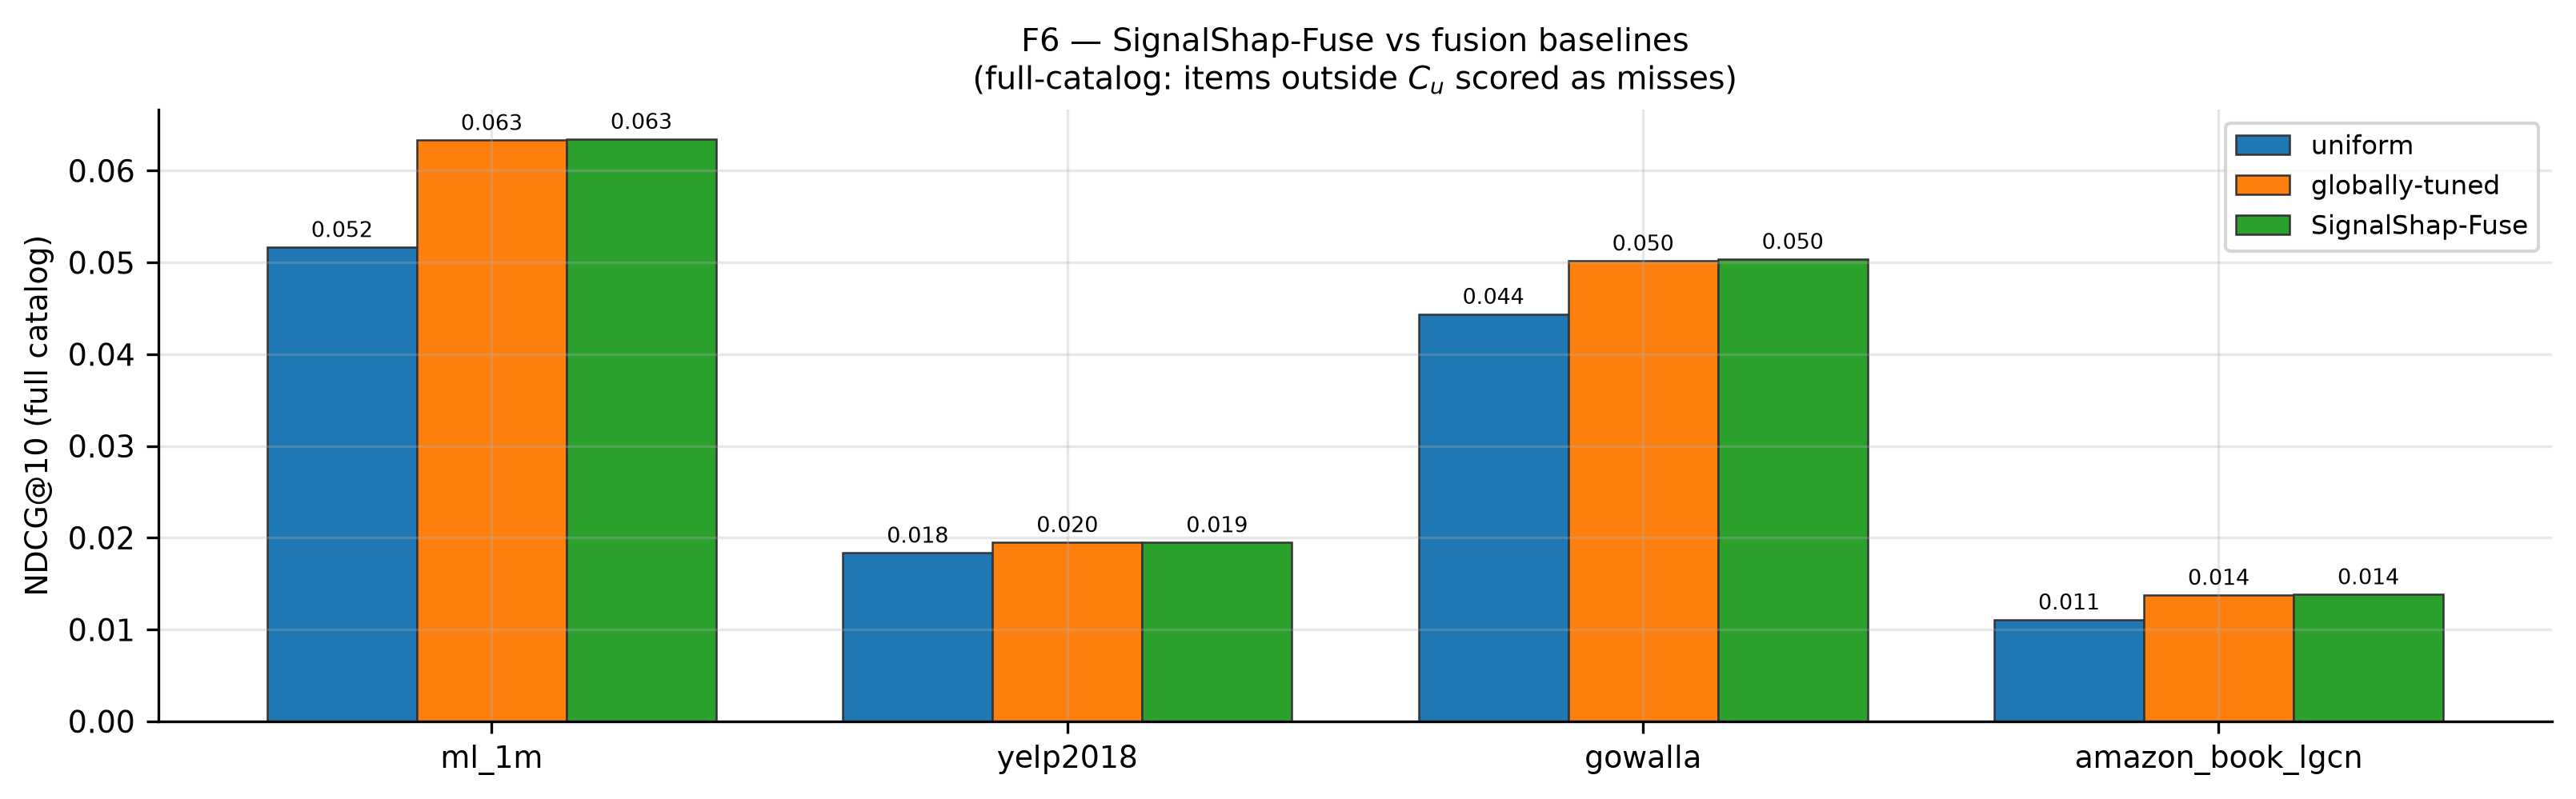

In [16]:
from IPython.display import Image, display as disp
for f in ["F2_shapley_shares","F3_loo_vs_shapley","F4_redundancy_heatmap","F6_fuse_gain"]:
    p = FIG/f"{f}.png"
    if p.exists(): print(f); disp(Image(filename=str(p)))

## 8 · Verify invariants

The tests that keep the work honest: the counterexample pinning the monotonicity hypothesis, and the density-ordering guard (which re-arms once three or more corpora are present).

In [17]:
r = subprocess.run([sys.executable,"-m","pytest","tests/","-q","--no-header"],
                   capture_output=True, text=True)
print(r.stdout[-1800:])


no tests ran in 0.00s



## 9 · Build the PDF

Needs a TeX distribution: `brew install --cask mactex-no-gui` (or BasicTeX + `tlmgr install
natbib booktabs helvetic`).

In [18]:
tex = subprocess.run(["which","pdflatex"], capture_output=True, text=True).stdout.strip()
if tex:
    print(subprocess.run(["make","-C","paper"], capture_output=True, text=True).stdout[-800:])
    print("PDF:", (REPO/"paper"/"paper.pdf").exists())
else:
    print("pdflatex not found — install MacTeX, then run:  make -C paper")

pdflatex not found — install MacTeX, then run:  make -C paper


## 10 · Summary

Written to `artefacts/`: `results_<corpus>.json`, `e9_recovery_<corpus>.json`,
`dataset_stats.json`, `figures/F1–F7.png`, `tables/T1–T8.{md,tex,csv}`.

**Read T2 before anything else** — candidate recall bounds every metric below it, and the
monotonicity column decides whether Property 2 applies.

### What to check before submitting
1. Every corpus clears the **0.60 recall gate**, or is reported conditional on its ceiling
2. The **intervention** holds on all four (symmetry < 1e-6, LOO ≈ 0)
3. **No synthetic results** leak into `paper/` — the loader warns loudly if raw files are missing
4. Protocol differences (no timestamps on three corpora; subsampling) stay disclosed in §Limitations

In [19]:
print("ARTEFACTS")
for p in sorted(Path("artefacts").rglob("*")):
    if p.is_file() and p.suffix in {".json",".png",".tex"}:
        print(f"  {p}  ({p.stat().st_size/1024:.0f} KB)")

print("\nHEADLINE")
for k, r in results.items():
    c = recovery[k]["conditions"]["eta=0.0"]
    print(f"  {k:18s} density={r['dataset_stats']['density']*100:.4f}%  "
          f"recall={r['e0a_candidates']['candidate_recall']:.3f}  "
          f"symmetry_err={c['symmetry_abs_error']:.1e}  LOO={c['loo_original']:.5f}")
print("\n'Exact' = exact GIVEN THE FITTED v. No sampling error; not no error.")

ARTEFACTS

HEADLINE
  ml_1m              density=2.6967%  recall=0.748  symmetry_err=0.0e+00  LOO=0.00000
  yelp2018           density=0.1046%  recall=0.818  symmetry_err=0.0e+00  LOO=0.00000
  gowalla            density=0.0719%  recall=0.678  symmetry_err=0.0e+00  LOO=0.00000
  amazon_book_lgcn   density=0.0547%  recall=0.529  symmetry_err=0.0e+00  LOO=0.00000

'Exact' = exact GIVEN THE FITTED v. No sampling error; not no error.


In [20]:
!export SIGNALSHAP_STRICT_DATA=1


Python(60094) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [22]:
!python scripts/run_study.py --datasets ml_1m --seeds 42 43 44 45 46 47 48 49 50 51


/opt/homebrew/Cellar/python@3.12/3.12.13_4/Frameworks/Python.framework/Versions/3.12/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/mlouhichi/signalshap-code/scripts/run_study.py': [Errno 2] No such file or directory


Python(24146) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:
!nohup python ../scripts/run_final_revision.py --budget-gb 24 > /tmp/final.log 2>&1 & tail -f /tmp/final.log

budget 24.0 GB | corpora ['ml_1m', 'amazon_video_games', 'gowalla_ts'] | seeds (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
blocks: ['seeds', 'lambda', 'friedman', 'retire']

== 10-seed attribution ==
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 42: 32s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 43: 33s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 44: 28s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 45: 30s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 46: 29s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 47: 30s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 48: 29s
[signalshap] ml_1m: loaded REAL data (6,038 use

In [4]:
!python ../scripts/run_study.py --datasets ml_1m --seeds 42 43 44          # ~11 min


memory budget: 15.4 GB (free: 25.6 GB)
ml_1m: ~10,599 items (est, probe saw 3,533) -> 45,262 users fit a 15 GB budget
  ml_1m: loaded 6,038 users x 3,533 items (0.4 GB of scores)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)

complete in 326s
  ml_1m        recall=0.748 PASS  monotonicity 22/80


In [5]:
!python ../scripts/run_study.py --datasets amazon_video_games --budget-gb 24 --seeds 42 43 44


memory budget: 24.0 GB (free: 22.5 GB)
amazon_video_games: ~10,242 items (est, probe saw 3,414) -> 73,227 users fit a 24 GB budget
  amazon_video_games: loaded 7,120 users x 3,516 items (0.5 GB of scores)
[signalshap] amazon_video_games: loaded REAL data (7,120 users x 3,516 items, 117,468 interactions)
[signalshap] amazon_video_games: loaded REAL data (7,120 users x 3,516 items, 117,468 interactions)
[signalshap] amazon_video_games: loaded REAL data (7,120 users x 3,516 items, 117,468 interactions)
[signalshap] amazon_video_games: loaded REAL data (7,120 users x 3,516 items, 117,468 interactions)

complete in 417s
  amazon_video_games recall=0.588 FAIL <- see spec §2.2 ladder  monotonicity 11/80


In [6]:
!python ../scripts/run_study.py --datasets gowalla_ts --budget-gb 24 --seeds 42 43 44   # ~3 h


memory budget: 24.0 GB (free: 28.6 GB)
gowalla_ts: ~84,594 items (est, probe saw 28,198) -> 8,865 users fit a 24 GB budget
  gowalla_ts: loaded 8,865 users x 82,134 items (14.6 GB of scores)
[signalshap] gowalla_ts: loaded REAL data (8,865 users x 82,134 items, 542,970 interactions)
[signalshap] gowalla_ts: loaded REAL data (8,865 users x 82,134 items, 542,970 interactions)
[signalshap] gowalla_ts: loaded REAL data (8,865 users x 82,134 items, 542,970 interactions)
[signalshap] gowalla_ts: loaded REAL data (8,865 users x 82,134 items, 542,970 interactions)

complete in 19306s
  gowalla_ts   recall=0.450 FAIL <- see spec §2.2 ladder  monotonicity 13/80


In [7]:
!python ../scripts/run_revision_experiments.py --dataset ml_1m


E13 analytic games: {'n_games': 6, 'all_pass': True, 'worst_error': 4.440892098500626e-16}
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
setup 22s  users=6038
E10 values: shapley top=seq banzhaf top=seq agree=True
E11 estimands (126s): refit_vs_fixed=+1.00, refit_vs_e2e=+0.80, fixed_vs_e2e=+0.80
E12 retirement (31s): shapley tau=+0.20 loo tau=+1.00 cheapest true=cf
done


In [8]:
!python ../scripts/run_final_revision.py --budget-gb 24                    # ~8 h


budget 24.0 GB | corpora ['ml_1m', 'amazon_video_games', 'gowalla_ts'] | seeds (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
blocks: ['seeds', 'lambda', 'friedman', 'retire']

== 10-seed attribution ==
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 42: 22s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 43: 22s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 44: 22s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 45: 22s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 46: 22s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 47: 22s
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 48: 22s
[signalshap] ml_1m: loaded REAL data (6,038 use

In [9]:
!python ../scripts/make_assets.py


  [rung 2] amazon_video_games: recall 0.588 below gate, exemption declared; RELATIVE contrasts only, excluded from absolute NDCG
  [rung 2] gowalla_ts: recall 0.450 below gate, exemption declared; RELATIVE contrasts only, excluded from absolute NDCG
  F1: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F1_workflow.png
  F2: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F2_shapley_shares.png
  F3: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F3_loo_vs_shapley.png
  F4: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F4_redundancy_heatmap.png
  F5: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F5_segment_radar.png
  F6: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F6_fuse_gain.png
  F7: /Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/artefacts/figures/F7_

In [ ]:
!bash ../scripts/rerun_all.sh 24


budget 24 GB | started 12:40:22

=== study_ml_1m  (log: logs/study_ml_1m.log) ===
    OK in 9m46s

=== study_amazon  (log: logs/study_amazon.log) ===
    OK in 13m09s

=== study_gowalla  (log: logs/study_gowalla.log) ===
    OK in 225m55s

=== revision_ml_1m  (log: logs/revision_ml_1m.log) ===
    OK in 3m00s

=== revision_amazon  (log: logs/revision_amazon.log) ===
    OK in 3m52s

=== revision_gowalla  (log: logs/revision_gowalla.log) ===
../scripts/rerun_all.sh: line 24: 43282 Killed: 9               "$@" > "$log" 2>&1
    FAILED after 5m01s -- see logs/revision_gowalla.log
      E13 analytic games: {'n_games': 6, 'all_pass': True, 'worst_error': 4.440892098500626e-16}
      [signalshap] gowalla_ts: loaded REAL data (52,985 users x 121,866 items, 3,301,571 interactions)

=== final_revision  (log: logs/final_revision.log) ===


In [13]:
!python ../scripts/run_final_revision.py --only seeds --budget-gb 16


budget 16.0 GB | corpora ['ml_1m', 'amazon_video_games', 'gowalla_ts'] | seeds (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
blocks: ['seeds']

== 10-seed attribution ==
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 42: 21s (1/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 43: 21s (2/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 44: 22s (3/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 45: 22s (4/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 46: 21s (5/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 47: 22s (6/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL

In [14]:
!python ../scripts/run_final_revision.py --only seeds

budget 12.6 GB | corpora ['ml_1m', 'amazon_video_games', 'gowalla_ts'] | seeds (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
blocks: ['seeds']

== 10-seed attribution ==
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 42: 36s (1/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 43: 47s (2/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 44: 50s (3/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 45: 46s (4/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 46: 42s (5/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 47: 38s (6/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL

In [16]:
!python ../scripts/run_final_revision.py --only seeds retire --budget-gb 24


budget 24.0 GB | corpora ['ml_1m', 'amazon_video_games', 'gowalla_ts'] | seeds (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
blocks: ['seeds', 'retire']

== 10-seed attribution ==
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 42: 23s (1/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 43: 23s (2/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 44: 23s (3/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 45: 22s (4/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 46: 22s (5/10 done, checkpointed)
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 47: 23s (6/10 done, checkpointed)
[signalshap] ml_1m: l

In [17]:
!python ../scripts/run_protocol_sensitivity.py --corpora ml_1m amazon_video_games gowalla_ts --budget-gb 24

== ml_1m: temporal state
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
== ml_1m: validation misses
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
   tau=1.00 maxdelta=1.46e-02 top seq->seq
== amazon_video_games: temporal state
[signalshap] amazon_video_games: loaded REAL data (7,120 users x 3,516 items, 117,468 interactions)
== amazon_video_games: validation misses
[signalshap] amazon_video_games: loaded REAL data (7,120 users x 3,516 items, 117,468 interactions)
   tau=0.80 maxdelta=6.08e-03 top cf->seq
== gowalla_ts: temporal state
[signalshap] gowalla_ts: loaded REAL data (52,985 users x 121,866 items, 3,301,571 interactions)


In [18]:
!python ../scripts/audit_global_time.py --corpora ml_1m amazon_video_games gowalla_ts


[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
ml_1m: 100.0% of test events precede global t_max; mean future-train fraction 44.2%
[signalshap] amazon_video_games: loaded REAL data (7,120 users x 3,516 items, 117,468 interactions)
amazon_video_games: 100.0% of test events precede global t_max; mean future-train fraction 27.1%
[signalshap] gowalla_ts: loaded REAL data (52,985 users x 121,866 items, 3,301,571 interactions)
gowalla_ts: 100.0% of test events precede global t_max; mean future-train fraction 19.4%


In [19]:
!python ../scripts/run_protocol_sensitivity.py --corpora gowalla_ts --budget-gb 24


/Users/mlouhichi/Desktop/personal/phd/next-paper/signalshap-code/src/signalshap/game/core.py:347: SyntaxWarning: invalid escape sequence '\{'
  reviewer showed that v(G) - v(G\{g}) then carries a spurious
== gowalla_ts: temporal state
[signalshap] gowalla_ts: loaded REAL data (52,985 users x 121,866 items, 3,301,571 interactions)


In [20]:
!python ../scripts/run_final_revision.py --only retire --budget-gb 24   # raw-utility losses

budget 24.0 GB | corpora ['ml_1m', 'amazon_video_games', 'gowalla_ts'] | seeds (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
blocks: ['retire']


== retirement over seeds ==
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 42: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 43: tau_shap=+0.20 tau_loo=+0.80
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 44: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 45: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 46: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 47: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL d

In [21]:
!python ../scripts/run_protocol_sensitivity.py --corpora gowalla_ts --budget-gb 24


budget 24.0 GB | corpora ['gowalla_ts']
gowalla_ts: ~84,594 items (est, probe saw 28,198) -> 8,865 users fit a 24 GB budget
== gowalla_ts: temporal state
[signalshap] gowalla_ts: loaded REAL data (8,865 users x 82,134 items, 542,970 interactions)
== gowalla_ts: validation misses
[signalshap] gowalla_ts: loaded REAL data (8,865 users x 82,134 items, 542,970 interactions)
   tau=1.00 maxdelta=8.11e-04 top cf->cf


In [22]:
!python ../scripts/run_final_revision.py --only retire --budget-gb 24


budget 24.0 GB | corpora ['ml_1m', 'amazon_video_games', 'gowalla_ts'] | seeds (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
blocks: ['retire']


== retirement over seeds ==
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 42: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 43: tau_shap=+0.20 tau_loo=+0.80
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 44: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 45: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 46: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL data (6,038 users x 3,533 items, 575,276 interactions)
  ml_1m seed 47: tau_shap=+0.20 tau_loo=+1.00
[signalshap] ml_1m: loaded REAL d